## Obtain a list of all the Mangopare files

In [1]:
import pandas as pd

url = (
    'https://erddap.emodnet-physics.eu/erddap/files/moanaproject/.csv'
    '?page=1'
    '&itemsPerPage=1000'
    '&searchFor='
    '&protocol=(ANY)'
    '&cdm_data_type=(ANY)'
    '&institution=(ANY)'
    '&ioos_category=(ANY)'
    '&keywords=(ANY)'
    '&long_name=(ANY)'
    '&standard_name=(ANY)'
    '&variableName=(ANY)'
)

dft = pd.read_csv(url)  

print('Mangopare Files Found = {}'.format(len(dft)))
print(url)
dft

Mangopare Files Found = 5309
https://erddap.emodnet-physics.eu/erddap/files/moanaproject/.csv?page=1&itemsPerPage=1000&searchFor=&protocol=(ANY)&cdm_data_type=(ANY)&institution=(ANY)&ioos_category=(ANY)&keywords=(ANY)&long_name=(ANY)&standard_name=(ANY)&variableName=(ANY)


,Name,Last modified,Size,Description
0,MOANA_20231014_175140_published.nc,1705569230000,107378,NaN
1,MOANA_20231017_212223_published.nc,1705569231000,106298,NaN
2,MOANA_20231018_030555_published.nc,1705569232000,48153,NaN
3,MOANA_20231018_031252_published.nc,1705569233000,70134,NaN
4,MOANA_20231018_033751_published.nc,1705569234000,50194,NaN
...,...,...,...,...
5304,MOANA_20240410_032045_published.nc,1712779227000,54493,NaN
5305,MOANA_20240410_032821_published.nc,1712779228000,54567,NaN
5306,MOANA_20240410_054610_published.nc,1712779230000,54493,NaN
5307,MOANA_20240410_072447_published.nc,1712779231000,54567,NaN


## Extraction of mangopare data using conditions

In [2]:
def download_moana(program='moanaproject', start='2024-01-01T00:00:00Z', stop='2024-01-10T00:00:00Z', lat_min=-60, lat_max=-25, lon_min=160, lon_max=180,depth_min=0,depth_max=1300):
    from pandas import DataFrame, read_csv
    from urllib.parse import quote
    #    from urllib.error import HTTPError
    base_url = f'https://erddap.emodnet-physics.eu/erddap/tabledap/{program}.csv?time,latitude,longitude,TEMP,depth,QC_FLAG,TIME_QC,POSITION_QC,TEMP_QC,DEPTH_QC'
    conditions = ('&time>={}'
            '&time<={}'
            '&latitude>={}'
            '&latitude<={}'
            '&longitude>={}'
            '&longitude<={}'
            '&depth>={}'
            '&depth<={}').format
    encoded_conditions = quote(conditions(start,stop,lat_min,lat_max,lon_min,lon_max,depth_min,depth_max))
    url = base_url+encoded_conditions
    print(f"Download link {url}")
    # Not sure if returning an empty df is the best idea.
    try:
        df = read_csv(url, parse_dates=True, skiprows=[1])
    except Exception as e:
        print(f"An error occurred: {e}")
    return df

Find all the surface temperatures available for the BoP region

In [3]:
dfs = download_moana(start='2023-10-11T00:00:00Z', stop='2024-04-10T23:00:00Z', lat_min=-39, lat_max=-30, lon_min=170, lon_max=180,depth_min=0,depth_max=1300)
dfs['time'] = pd.to_datetime(dfs['time'])

Download link https://erddap.emodnet-physics.eu/erddap/tabledap/moanaproject.csv?time,latitude,longitude,TEMP,depth,QC_FLAG,TIME_QC,POSITION_QC,TEMP_QC,DEPTH_QC%26time%3E%3D2023-10-11T00%3A00%3A00Z%26time%3C%3D2024-04-10T23%3A00%3A00Z%26latitude%3E%3D-39%26latitude%3C%3D-30%26longitude%3E%3D170%26longitude%3C%3D180%26depth%3E%3D0%26depth%3C%3D1300


In [4]:
dfs

,time,latitude,longitude,TEMP,depth,QC_FLAG,TIME_QC,POSITION_QC,TEMP_QC,DEPTH_QC
0,2023-10-17 23:39:45+00:00,-36.231505,175.070043,16.359,1.191204,3,1,2,3,1
1,2023-10-17 23:39:47+00:00,-36.231505,175.070043,16.055,2.580934,2,1,2,1,1
2,2023-10-17 23:39:49+00:00,-36.231505,175.070043,15.958,4.069919,2,1,2,1,1
3,2023-10-17 23:39:51+00:00,-36.231505,175.070043,15.881,5.658158,2,1,2,1,1
4,2023-10-17 23:39:53+00:00,-36.231505,175.070043,15.796,7.345649,2,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...
83001,2024-04-10 02:20:26+00:00,-36.225893,175.052898,19.615,7.742718,2,1,2,1,1
83002,2024-04-10 02:20:30+00:00,-36.225893,175.052898,19.615,8.735353,2,1,2,1,1
83003,2024-04-10 02:20:36+00:00,-36.225893,175.052898,19.615,9.827246,2,1,2,1,1
83004,2024-04-10 02:20:43+00:00,-36.225893,175.052898,19.654,3.474333,2,1,2,1,1


[Text(19647.0, 0, '2023-10-17'),
 Text(19657.0, 0, '2023-10-27'),
 Text(19667.0, 0, '2023-11-06'),
 Text(19677.0, 0, '2023-11-16'),
 Text(19687.0, 0, '2023-11-26'),
 Text(19697.0, 0, '2023-12-06'),
 Text(19707.0, 0, '2023-12-16'),
 Text(19717.0, 0, '2023-12-26'),
 Text(19727.0, 0, '2024-01-05'),
 Text(19737.0, 0, '2024-01-15'),
 Text(19747.0, 0, '2024-01-25'),
 Text(19757.0, 0, '2024-02-04'),
 Text(19767.0, 0, '2024-02-14'),
 Text(19777.0, 0, '2024-02-24'),
 Text(19787.0, 0, '2024-03-05'),
 Text(19797.0, 0, '2024-03-15'),
 Text(19807.0, 0, '2024-03-25'),
 Text(19817.0, 0, '2024-04-04')]

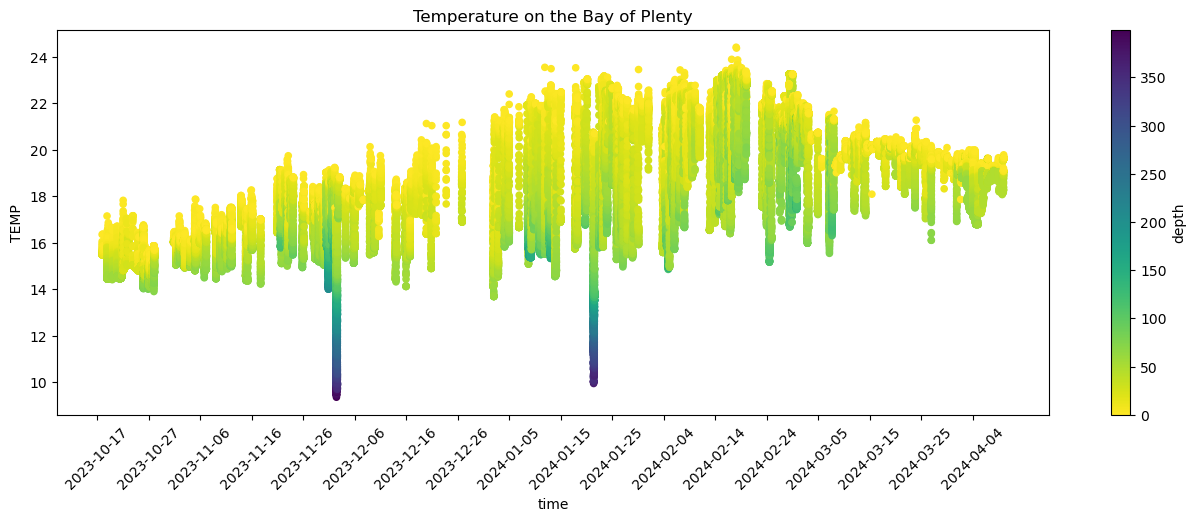

In [5]:
ax = dfs.plot(kind='scatter',x='time',y='TEMP', c='depth', colormap='viridis_r', marker='o', figsize=(16,5), title='Temperature on the Bay of Plenty')
time=pd.date_range(start='2023-10-17T00:00:00Z', end='2024-04-10T23:00:00Z', freq='10D')
ax.set_xticks(time.strftime('%Y-%m-%d'))
ax.set_xticklabels(time.strftime('%Y-%m-%d'), rotation=45)